# Important Parameter Separation

This notebook analyzes how benign vs malicious clients affect safety-critical parameters using safety-score based masks from wandg/snip-style artifacts.

The notebook stays minimal: load the saved score artifacts, build masks, and compare client updates against a harmful reference.

In [1]:
import math
import os
import pickle
import re

import numpy as np
import torch
from tqdm import tqdm
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
snip_attribution_paths = '/home/ps9044/safety-attribution/weietal/out49/llama2-7b-chat-hf/unstructured/wanda_weightonly'
utility_attribution_path = os.path.join(snip_attribution_paths, 'alpaca_cleaned_no_safety/wanda_score/alpaca_cleaned_no_safety_weight_only_disentangle')
safety_attribution_path = os.path.join(snip_attribution_paths, 'align/wanda_score/align_weight_only_disentangle')

_LORA_PARAM_RE = re.compile(r'^base_model\.model\.model\.layers\.(\d+)\.(.+)\.lora_[AB]\.weight$')


def parse_lora_param_name(param_name):
    match = _LORA_PARAM_RE.match(param_name)
    if match is None:
        return None
    layer_idx = int(match.group(1))
    module_name = match.group(2)
    return layer_idx, module_name


def score_path_for_param(param_name, attribution_root):
    parsed = parse_lora_param_name(param_name)
    if parsed is None:
        return None
    layer_idx, module_name = parsed
    return os.path.join(
        attribution_root,
        # f'W_metric_layer_{layer_idx}_name_model.layers.{layer_idx}.{module_name}_weight.pkl',
        f'W_metric_layer_{layer_idx}_name_{module_name}_align_weight_only_disentangle.pkl'
    )


def safety_score_path_for_param(param_name, attribution_root=safety_attribution_path):
    return score_path_for_param(param_name, attribution_root)


def utility_score_path_for_param(param_name, attribution_root=utility_attribution_path):
    return score_path_for_param(param_name, attribution_root)

In [ ]:
def _bottom_fraction_mask(scores, bottom_fraction):
    scores = torch.as_tensor(scores).detach().cpu().float()
    flat = scores.abs().reshape(-1)
    if flat.numel() == 0:
        return torch.zeros_like(scores, dtype=torch.bool)
    keep = max(1, int(math.ceil(flat.numel() * float(bottom_fraction))))
    threshold = torch.topk(flat, keep, largest=False).values.max()
    return scores.abs() <= threshold


def _collect_lora_pairs(local_dict):
    grouped = {}
    for param_name, param in local_dict.items():
        if not torch.is_tensor(param):
            continue
        parsed = parse_lora_param_name(param_name)
        if parsed is None:
            continue
        layer_idx, module_name = parsed
        bucket = grouped.setdefault((layer_idx, module_name), {})
        if '.lora_A.weight' in param_name:
            bucket['A'] = param.detach().cpu().float()
        elif '.lora_B.weight' in param_name:
            bucket['B'] = param.detach().cpu().float()
    return grouped


def _ordered_lora_module_keys(local_dict):
    ordered = []
    seen = set()
    for param_name in local_dict:
        parsed = parse_lora_param_name(param_name)
        if parsed is None:
            continue
        if parsed in seen:
            continue
        seen.add(parsed)
        ordered.append(parsed)
    return ordered


def _mask_cache_path(cache_dir, mode, p, q):
    if cache_dir is None:
        return None
    os.makedirs(cache_dir, exist_ok=True)
    def _tag(value):
        text = f"{float(value):.6f}".rstrip('0').rstrip('.')
        return text.replace('.', 'p') if text else '0'
    return os.path.join(cache_dir, f'mask_cache_mode{mode}_p{_tag(p)}_q{_tag(q)}.pkl')


def load_neuron_masks(mask_path, threshold=0.5, inverse=False, map_location="cpu"):
    mask_state = torch.load(mask_path, map_location=map_location)
    masks = {}
    for name, logits in mask_state.items():
        logits = torch.as_tensor(logits).float()
        probs = torch.sigmoid(logits)
        mask = probs > float(threshold)
        if inverse:
            mask = ~mask
        masks[name] = mask
    return masks


def lookup_neuron_mask(neuron_masks, layer_idx, module_name):
    if not neuron_masks:
        return None
    candidates = (
        f"model.layers.{layer_idx}.{module_name}",
        f"base_model.model.model.layers.{layer_idx}.{module_name}",
        f"model.model.layers.{layer_idx}.{module_name}",
    )
    for key in candidates:
        if key in neuron_masks:
            return neuron_masks[key]
    return None


def precompute_score_masks(
    local_dict,
    safety_root,
    utility_root=None,
    p=0.1,
    q=None,
    mode=0,
    cache_dir=None,
    force=False,
):
    if q is None:
        q = p
    grouped = _collect_lora_pairs(local_dict)
    cache_path = _mask_cache_path(cache_dir, mode, p, q)
    meta = {
        'safety_root': safety_root,
        'utility_root': utility_root,
        'p': float(p),
        'q': float(q),
        'mode': int(mode),
    }
    if cache_path and not force and os.path.exists(cache_path):
        with open(cache_path, 'rb') as handle:
            payload = pickle.load(handle)
        if payload.get('meta') == meta:
            return payload.get('masks', {}), payload.get('missing_score_paths', [])
        
    masks = {}
    missing_score_paths = []
    print('collected all lora weights')
    print(f'Example: {list(grouped.keys())[0]}')
    print(grouped[list(grouped.keys())[0]].keys())

    for (layer_idx, module_name), pair in tqdm(sorted(grouped.items())):
        if 'A' not in pair or 'B' not in pair:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')
        delta_shape = (pair['B'].shape[0], pair['A'].shape[1])
        safety_path = safety_score_path_for_param(
            f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
            attribution_root=safety_root,
        )
        if safety_path is None or not os.path.exists(safety_path):
            missing_score_paths.append(safety_path)
            raise ValueError(f'safety score path not found for layer {layer_idx} module {module_name}: {safety_path}')
            continue
        with open(safety_path, 'rb') as handle:
            safety_score = pickle.load(handle)
        # print(safety_score.mean())
        safety_mask = _bottom_fraction_mask(safety_score, p)
        if safety_mask.shape != delta_shape:
            raise ValueError(
                f'mask shape mismatch for layer {layer_idx} {module_name}: '
                f'{tuple(safety_mask.shape)} vs {tuple(delta_shape)}',
            )

        utility_mask = None
        if mode == 1:
            if utility_root is None:
                raise ValueError('utility_root is required when mode=1')
            utility_path = utility_score_path_for_param(
                f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                attribution_root=utility_root,
            )
            if utility_path is None or not os.path.exists(utility_path):
                missing_score_paths.append(utility_path)
                continue
            with open(utility_path, 'rb') as handle:
                utility_score = pickle.load(handle)
            utility_mask = _bottom_fraction_mask(utility_score, q)
            if utility_mask.shape != delta_shape:
                raise ValueError(
                    f'utility mask shape mismatch for layer {layer_idx} {module_name}: '
                    f'{tuple(utility_mask.shape)} vs {tuple(delta_shape)}',
                )
        masks[(layer_idx, module_name)] = {
            'safety': safety_mask,
            'utility': utility_mask,
        }

    if cache_path:
        payload = {
            'meta': meta,
            'masks': masks,
            'missing_score_paths': missing_score_paths,
        }
        with open(cache_path, 'wb') as handle:
            pickle.dump(payload, handle)
    return masks, missing_score_paths


def calculate_parameter_change(
    local_dict,
    safety_root,
    utility_root=None,
    p=0.1,
    q=None,
    mode=0,
    precomputed_masks=None,
    neuron_masks=None,
    reference_data=None,
    mask_source="score",
):
    """Compute masked delta-W norms for LoRA modules.

    mask_source options:
      - "score": original notebook behavior. Build the full delta-W mask from safety/utility attribution scores.
      - "saved_neuron": use only the saved AblatedLinear neuron mask from best_safety_masks.pt/final_safety_masks.pt.
      - "score_and_saved_neuron": intersect the attribution-score mask with the saved neuron mask.

    Notes:
      The saved AblatedLinear mask is one boolean per output neuron for each linear layer.
      LoRA delta_w has shape [out_features, in_features], so the saved neuron mask is expanded
      over columns as neuron_mask[:, None].expand_as(delta_w).
    """
    valid_mask_sources = {"score", "saved_neuron", "score_and_saved_neuron"}
    if mask_source not in valid_mask_sources:
        raise ValueError(f"mask_source must be one of {sorted(valid_mask_sources)}, got {mask_source!r}")

    if q is None:
        q = p

    grouped = _collect_lora_pairs(local_dict)
    ordered_keys = _ordered_lora_module_keys(local_dict)
    if len(ordered_keys) != len(grouped):
        ordered_keys = sorted(grouped.keys())
    if reference_data is None:
        raise ValueError('reference_data is required for cosine similarity')
    if len(reference_data) != len(ordered_keys):
        raise ValueError(
            f'reference_data length {len(reference_data)} does not match '
            f'lora module count {len(ordered_keys)}',
        )

    module_stats = []
    missing_score_paths = []
    missing_neuron_masks = []

    for ref_idx, (layer_idx, module_name) in enumerate(ordered_keys):
        pair = grouped.get((layer_idx, module_name))
        if pair is None:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')
        if 'A' not in pair or 'B' not in pair:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')

        assert pair['B'].shape[1] < 50
        delta_w = pair['B'] @ pair['A']

        safety_path = None
        utility_path = None
        mask = None

        # Original score-based mask path.
        if mask_source in {"score", "score_and_saved_neuron"}:
            mask_entry = None
            if precomputed_masks is not None:
                mask_entry = precomputed_masks.get((layer_idx, module_name))

            if mask_entry is not None:
                safety_mask = mask_entry['safety']
                utility_mask = mask_entry.get('utility')
            else:
                safety_path = safety_score_path_for_param(
                    f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                    attribution_root=safety_root,
                )
                if safety_path is None or not os.path.exists(safety_path):
                    missing_score_paths.append(safety_path)
                    continue
                with open(safety_path, 'rb') as handle:
                    safety_score = pickle.load(handle)
                safety_mask = _bottom_fraction_mask(safety_score, p)

                utility_mask = None
                if mode == 1:
                    if utility_root is None:
                        raise ValueError('utility_root is required when mode=1')
                    utility_path = utility_score_path_for_param(
                        f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                        attribution_root=utility_root,
                    )
                    if utility_path is None or not os.path.exists(utility_path):
                        missing_score_paths.append(utility_path)
                        continue
                    with open(utility_path, 'rb') as handle:
                        utility_score = pickle.load(handle)
                    utility_mask = _bottom_fraction_mask(utility_score, q)

            if safety_mask.shape != delta_w.shape:
                raise ValueError(
                    f'mask shape mismatch for layer {layer_idx} {module_name}: '
                    f'{tuple(safety_mask.shape)} vs {tuple(delta_w.shape)}',
                )

            mask = safety_mask
            if mode == 1:
                if utility_mask is None:
                    raise ValueError(f'utility mask missing for layer {layer_idx} {module_name}')
                if utility_mask.shape != delta_w.shape:
                    raise ValueError(
                        f'utility mask shape mismatch for layer {layer_idx} {module_name}: '
                        f'{tuple(utility_mask.shape)} vs {tuple(delta_w.shape)}',
                    )
                mask = safety_mask & (~utility_mask)

        # Saved AblatedLinear neuron mask path.
        if mask_source in {"saved_neuron", "score_and_saved_neuron"}:
            neuron_mask = lookup_neuron_mask(neuron_masks, layer_idx, module_name)
            if neuron_mask is None:
                missing_neuron_masks.append((layer_idx, module_name))
                raise ValueError(f'neuron mask not found for layer {layer_idx} module {module_name}')
                continue
            if neuron_mask.numel() != delta_w.shape[0]:
                raise ValueError(
                    f'neuron mask shape mismatch for layer {layer_idx} {module_name}: '
                    f'{int(neuron_mask.numel())} vs {int(delta_w.shape[0])}',
                )
            expanded_neuron_mask = neuron_mask[:, None].expand_as(delta_w)
            mask = expanded_neuron_mask if mask is None else (mask & expanded_neuron_mask)

        if mask is None:
            raise ValueError(
                f'no mask was created for layer {layer_idx} module {module_name}; '
                f'check mask_source={mask_source!r}'
            )

        masked_delta = delta_w[mask]
        reference_vec = reference_data[ref_idx]
        reference_vec = reference_vec[mask]
        cosine_sim = torch.nn.functional.cosine_similarity(
            masked_delta.flatten(),
            -reference_vec.flatten(),
            dim=0,
        )

        module_stats.append(
            {
                'layer_idx': layer_idx,
                'module_name': module_name,
                'mask_source': mask_source,
                'safety_score_path': safety_path,
                'utility_score_path': utility_path,
                'masked_l2': float(torch.linalg.norm(masked_delta).item()),
                'cosine_sim': float(cosine_sim.item()),
                'masked_l1_mean': float(masked_delta.abs().mean().item()) if masked_delta.numel() else 0.0,
                'masked_numel': int(masked_delta.numel()),
                'total_numel': int(delta_w.numel()),
                'masked_fraction': float(masked_delta.numel() / delta_w.numel()) if delta_w.numel() else 0.0,
            }
        )

    return {
        'n_lora_modules': int(len(grouped)),
        'n_scored_modules': int(len(module_stats)),
        'total_masked_l2': float(sum(item['masked_l2'] for item in module_stats)),
        'mean_masked_l1': float(np.mean([item['masked_l1_mean'] for item in module_stats])) if module_stats else 0.0,
        'module_stats': module_stats,
        'missing_score_paths': missing_score_paths,
        'missing_neuron_masks': missing_neuron_masks,
        'cosine_sim_sum': float(np.sum([item['cosine_sim'] for item in module_stats])) if module_stats else 0.0,
    }


### Saved-mask analysis mode

This notebook has been modified so `mask_source = "saved_neuron"` uses the mask saved by `AblatedLinear.save_masks(...)` instead of recalculating the attribution-score mask. Set `saved_neuron_mask_path` to your `best_safety_masks.pt` or `final_safety_masks.pt` file before running the analysis cell.


In [3]:
example_param_name = 'base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight'
print(safety_score_path_for_param(example_param_name))

run_save = '/scratch/ps9044/newsetting/BeaverTailsSafe5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260517123537'

# Saved mask produced by AblatedLinear.save_masks(...).
# The training code saves either:
#   ./neuron_paper/best_safety_masks.pt
#   ./neuron_paper/final_safety_masks.pt
# Change this to the exact path of your saved mask file.
saved_neuron_mask_path = '/home/ps9044/safety-attribution/SafeSeek/alignment/neuron_paper/best_safety_masks.pt'

# Use the saved AblatedLinear mask instead of the original attribution-score mask.
# Options:
#   "saved_neuron"          -> use only the saved mask
#   "score"                 -> original notebook behavior
#   "score_and_saved_neuron"-> intersection of original score mask and saved mask
mask_source = "saved_neuron"
neuron_mask_threshold = 0.5
use_inverse_neuron_mask = True  # set True if you want the complement of the saved mask

sparsity = 0.05  # only used when mask_source is "score" or "score_and_saved_neuron"
mask_mode = 0    # only used for score masks: 0 = safety only, 1 = safety minus utility
benign_clients = {0, 1, 2, 3, 4}
roundwise_param_changes = []
mask_cache_dir = os.path.join(run_save, 'mask_cache') if run_save else None
precomputed_masks = None
mask_cache_missing = []
reference_path = '/home/ps9044/RPA/fedllm-attack/delta_matrix_purebad10rounds_harmful_torch.float32.pkl'

key = 'cosine_sim_sum'
# key = 'total_masked_l2'

with open(reference_path, 'rb') as f:
    reference_data = pickle.load(f)

neuron_masks = None
if mask_source in {"saved_neuron", "score_and_saved_neuron"}:
    if not os.path.exists(saved_neuron_mask_path):
        raise FileNotFoundError(
            f"Saved neuron mask not found: {saved_neuron_mask_path}. "
            "Set saved_neuron_mask_path to your best_safety_masks.pt or final_safety_masks.pt file."
        )
    neuron_masks = load_neuron_masks(
        saved_neuron_mask_path,
        threshold=neuron_mask_threshold,
        inverse=use_inverse_neuron_mask,
        map_location="cpu",
    )
    print(f"Loaded {len(neuron_masks)} saved neuron masks from {saved_neuron_mask_path}")

if run_save:
    for round_idx in tqdm(range(1, 31)):
        round_path = os.path.join(run_save, f'round_{round_idx}.pkl')
        if not os.path.exists(round_path):
            continue
        with open(round_path, 'rb') as f:
            data = pickle.load(f)

        # Only precompute attribution-score masks when they are actually used.
        if mask_source in {"score", "score_and_saved_neuron"} and precomputed_masks is None:
            seed_client = data['clients'][0]
            precomputed_masks, mask_cache_missing = precompute_score_masks(
                data['local_dict_list'][seed_client],
                safety_root=safety_attribution_path,
                utility_root=utility_attribution_path,
                p=sparsity,
                q=sparsity,
                mode=mask_mode,
                cache_dir=mask_cache_dir,
                force=True
            )

        round_param_changes = []
        for client in data['clients']:
            summary = calculate_parameter_change(
                data['local_dict_list'][client],
                safety_root=safety_attribution_path,
                utility_root=utility_attribution_path,
                p=sparsity,
                q=sparsity,
                mode=mask_mode,
                precomputed_masks=precomputed_masks,
                neuron_masks=neuron_masks,
                reference_data=reference_data,
                mask_source=mask_source,
            )
            summary['client'] = client
            summary['group'] = 'benign' if client in benign_clients else 'malicious'
            round_param_changes.append(summary)
            print(f'Client {client} | {key}: {summary[key]}')
        roundwise_param_changes.append(round_param_changes)

preview = None
if roundwise_param_changes and roundwise_param_changes[0]:
    first = roundwise_param_changes[0][0]
    preview = {
        'client': first['client'],
        'group': first['group'],
        'mask_source': mask_source,
        'n_lora_modules': first['n_lora_modules'],
        'n_scored_modules': first['n_scored_modules'],
        'total_masked_l2': first['total_masked_l2'],
        'mean_masked_l1': first['mean_masked_l1'],
        'missing_score_paths': len(first.get('missing_score_paths', [])),
        'missing_neuron_masks': len(first.get('missing_neuron_masks', [])),
        'cosine_sim_sum': first['cosine_sim_sum'],
    }

print({
    'rounds_loaded': len(roundwise_param_changes),
    'preview': preview,
    'mask_cache_missing': len(mask_cache_missing),
})


/home/ps9044/safety-attribution/weietal/out49/llama2-7b-chat-hf/unstructured/wanda_weightonly/align/wanda_score/align_weight_only_disentangle/W_metric_layer_0_name_self_attn.q_proj_align_weight_only_disentangle.pkl
Loaded 224 saved neuron masks from /home/ps9044/safety-attribution/SafeSeek/alignment/neuron_paper/best_safety_masks.pt


  0%|          | 0/30 [00:00<?, ?it/s]

Client 0 | cosine_sim_sum: 5.53820819221437
Client 1 | cosine_sim_sum: 4.66308896895498
Client 2 | cosine_sim_sum: 5.373306207358837
Client 3 | cosine_sim_sum: 5.696133000776172
Client 4 | cosine_sim_sum: 5.513369084335864
Client 5 | cosine_sim_sum: 7.344528176821768
Client 6 | cosine_sim_sum: 7.355207499989774
Client 7 | cosine_sim_sum: 6.4179914449341595
Client 8 | cosine_sim_sum: 7.600150895304978


  3%|▎         | 1/30 [00:09<04:28,  9.26s/it]

Client 9 | cosine_sim_sum: 7.310049975756556
Client 0 | cosine_sim_sum: 7.905083262827247
Client 1 | cosine_sim_sum: 8.379465518519282
Client 2 | cosine_sim_sum: 8.045980617403984
Client 3 | cosine_sim_sum: 8.264910630881786
Client 4 | cosine_sim_sum: 7.6293483641929924
Client 5 | cosine_sim_sum: 8.588821478188038
Client 6 | cosine_sim_sum: 8.864420976489782
Client 7 | cosine_sim_sum: 8.795997954905033
Client 8 | cosine_sim_sum: 8.795937806367874


...

Client 9 | cosine_sim_sum: 6.9553349644411355
Client 0 | cosine_sim_sum: 6.956140722613782
Client 1 | cosine_sim_sum: 6.886317324824631
Client 2 | cosine_sim_sum: 6.9169689528644085
Client 3 | cosine_sim_sum: 6.949888700852171
Client 4 | cosine_sim_sum: 6.9111262306105345
Client 5 | cosine_sim_sum: 6.940645439084619
Client 6 | cosine_sim_sum: 6.956364086130634
Client 7 | cosine_sim_sum: 6.943750136531889
Client 8 | cosine_sim_sum: 6.969308951171115


 97%|█████████▋| 29/30 [03:44<00:07,  7.75s/it]

Client 9 | cosine_sim_sum: 6.948782823979855
Client 0 | cosine_sim_sum: 6.951479253359139
Client 1 | cosine_sim_sum: 6.904058219399303
Client 2 | cosine_sim_sum: 6.920365270692855
Client 3 | cosine_sim_sum: 6.93198191630654
Client 4 | cosine_sim_sum: 6.919294908409938
Client 5 | cosine_sim_sum: 6.951573275728151
Client 6 | cosine_sim_sum: 6.942091788165271
Client 7 | cosine_sim_sum: 6.9395539266988635
Client 8 | cosine_sim_sum: 6.962410177104175


100%|██████████| 30/30 [03:52<00:00,  7.75s/it]

Client 9 | cosine_sim_sum: 6.942511731293052
{'rounds_loaded': 30, 'preview': {'client': 0, 'group': 'benign', 'mask_source': 'saved_neuron', 'n_lora_modules': 64, 'n_scored_modules': 64, 'total_masked_l2': 0.10762372217141092, 'mean_masked_l1': 9.677082971393247e-06, 'missing_score_paths': 0, 'missing_neuron_masks': 0, 'cosine_sim_sum': 5.53820819221437}, 'mask_cache_missing': 0}


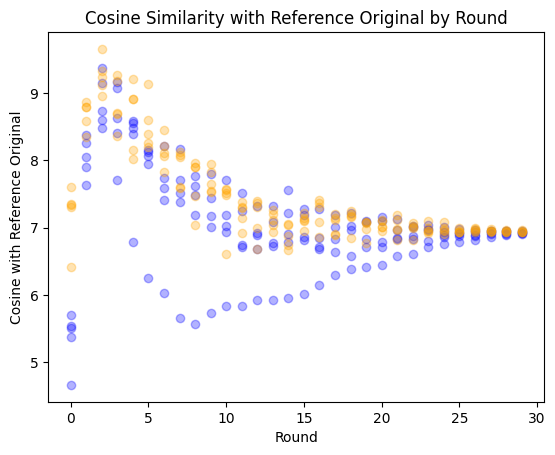

In [7]:
# plot 
import matplotlib.pyplot as plt
benigns = [0, 1, 2, 3, 4]
key = 'cosine_sim_sum'
for client in range(10):
    round_datas = []
    for round, round_data in enumerate(roundwise_param_changes):
        for client_data in round_data:
            if client_data['client'] == client:
                round_datas.append(client_data[key])
                break
        # print(round_datas)
        if client in benigns:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (benign)', marker='o', color='blue', alpha=0.3)
        else:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (malicious)', marker='o', color='orange', alpha=0.3)

        
plt.xlabel('Round')
# plt.ylabel('Total Masked L2 Change')
# plt.title('Total Masked L2 Change by Round')
plt.ylabel('Cosine with Reference Original')
plt.title('Cosine Similarity with Reference Original by Round')
plt.show()


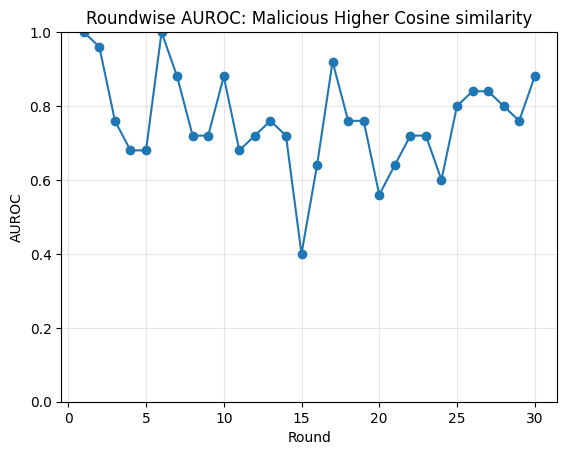

In [8]:
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

roundwise_aurocs = []

for round_idx, round_data in enumerate(roundwise_param_changes, start=1):
    y_true = []
    y_score = []

    for client_data in round_data:
        client = client_data['client']

        # malicious = 1, benign = 0
        y_true.append(0 if client in benign_clients else 1)

        # higher L2 means more malicious
        y_score.append(client_data[key])

    if len(set(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_score)
    else:
        auroc = np.nan

    roundwise_aurocs.append(auroc)

plt.figure()
plt.plot(
    range(1, len(roundwise_aurocs) + 1),
    roundwise_aurocs,
    marker='o'
)
plt.xlabel('Round')
plt.ylabel('AUROC')
plt.title('Roundwise AUROC: Malicious Higher Cosine similarity')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

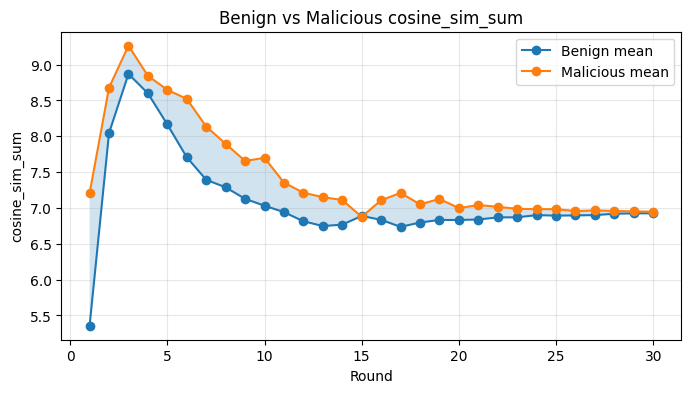

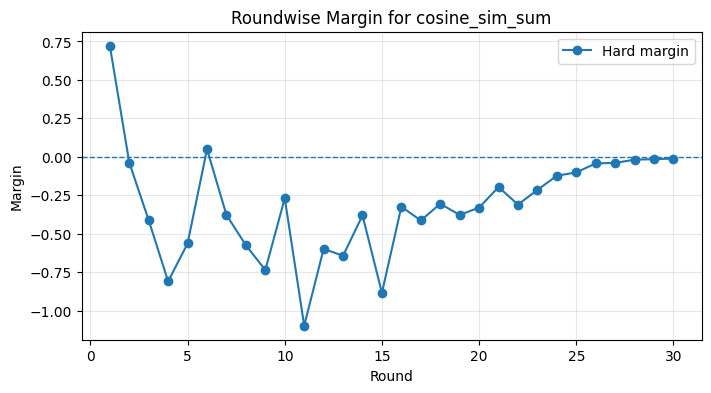

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rounds = []
benign_means = []
mal_means = []
mean_margins = []
hard_margins = []

for r, round_data in enumerate(roundwise_param_changes, start=1):
    benign_scores = []
    mal_scores = []

    for client_data in round_data:
        score = client_data[key]

        if client_data["client"] in benign_clients:
            benign_scores.append(score)
        else:
            mal_scores.append(score)

    if len(benign_scores) == 0 or len(mal_scores) == 0:
        continue

    benign_scores = np.array(benign_scores)
    mal_scores = np.array(mal_scores)

    rounds.append(r)
    benign_means.append(benign_scores.mean())
    mal_means.append(mal_scores.mean())

    mean_margins.append(mal_scores.mean() - benign_scores.mean())
    hard_margins.append(mal_scores.min() - benign_scores.max())

plt.figure(figsize=(8, 4))
plt.plot(rounds, benign_means, marker="o", label="Benign mean")
plt.plot(rounds, mal_means, marker="o", label="Malicious mean")
plt.fill_between(rounds, benign_means, mal_means, alpha=0.2)
plt.xlabel("Round")
plt.ylabel(key)
plt.title(f"Benign vs Malicious {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
# plt.plot(rounds, mean_margins, marker="o", label="Mean margin")
plt.plot(rounds, hard_margins, marker="o", label="Hard margin")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Round")
plt.ylabel("Margin")
plt.title(f"Roundwise Margin for {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

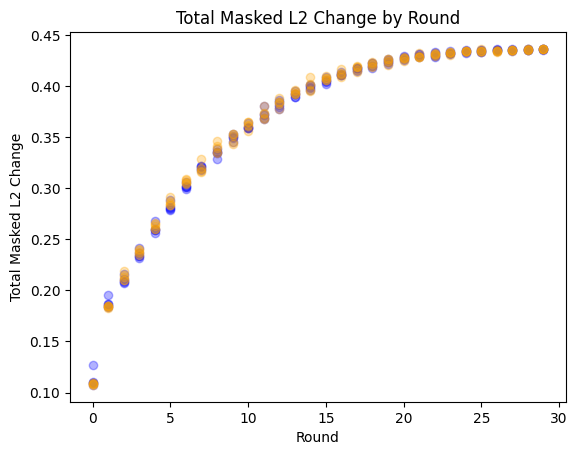

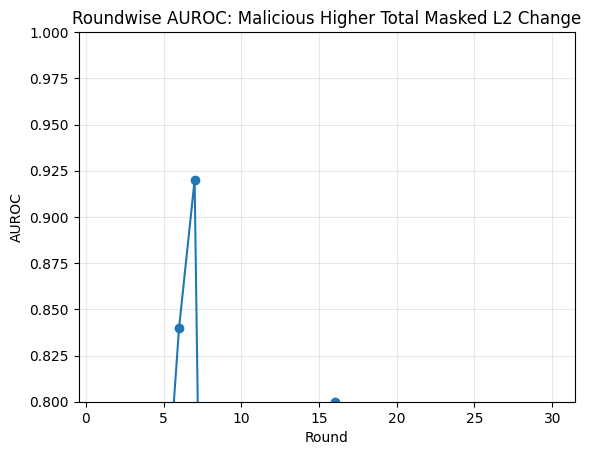

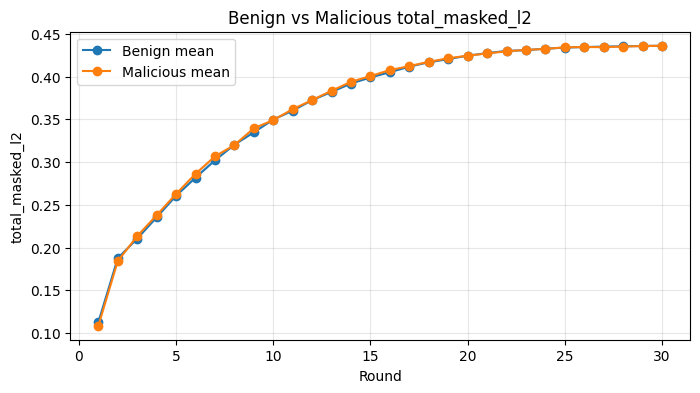

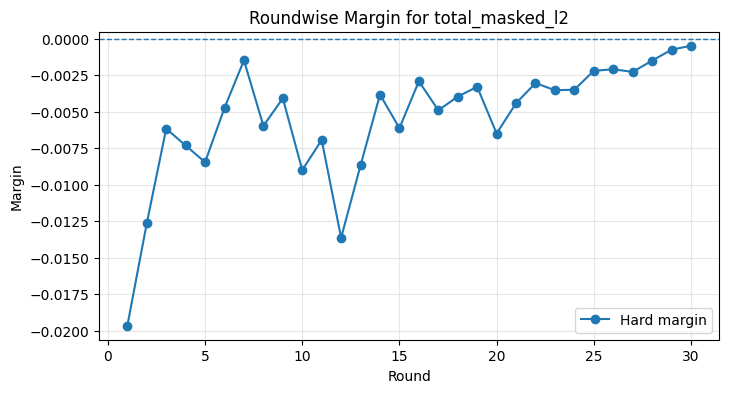

In [10]:

key = 'total_masked_l2'

# plot 

import matplotlib.pyplot as plt
benigns = [0, 1, 2, 3, 4]

for client in range(10):
    round_datas = []
    for round, round_data in enumerate(roundwise_param_changes):
        for client_data in round_data:
            if client_data['client'] == client:
                round_datas.append(client_data['total_masked_l2'])
                break
        # print(round_datas)
        if client in benigns:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (benign)', marker='o', color='blue', alpha=0.3)
        else:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (malicious)', marker='o', color='orange', alpha=0.3)

        
plt.xlabel('Round')
plt.ylabel('Total Masked L2 Change')
plt.title('Total Masked L2 Change by Round')
# plt.ylabel('Cosine with Reference Original')
# plt.title('Cosine Similarity with Reference Original by Round')
plt.show()


from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

roundwise_aurocs = []

for round_idx, round_data in enumerate(roundwise_param_changes, start=1):
    y_true = []
    y_score = []

    for client_data in round_data:
        client = client_data['client']

        # malicious = 1, benign = 0
        y_true.append(0 if client in benign_clients else 1)

        # higher L2 means more malicious
        y_score.append(client_data[key])

    if len(set(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_score)
    else:
        auroc = np.nan

    roundwise_aurocs.append(auroc)

plt.figure()
plt.plot(
    range(1, len(roundwise_aurocs) + 1),
    roundwise_aurocs,
    marker='o'
)
plt.xlabel('Round')
plt.ylabel('AUROC')
plt.title('Roundwise AUROC: Malicious Higher Total Masked L2 Change')
plt.ylim(0.8, 1)
plt.grid(True, alpha=0.3)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

rounds = []
benign_means = []
mal_means = []
mean_margins = []
hard_margins = []

for r, round_data in enumerate(roundwise_param_changes, start=1):
    benign_scores = []
    mal_scores = []

    for client_data in round_data:
        score = client_data[key]

        if client_data["client"] in benign_clients:
            benign_scores.append(score)
        else:
            mal_scores.append(score)

    if len(benign_scores) == 0 or len(mal_scores) == 0:
        continue

    benign_scores = np.array(benign_scores)
    mal_scores = np.array(mal_scores)

    rounds.append(r)
    benign_means.append(benign_scores.mean())
    mal_means.append(mal_scores.mean())

    mean_margins.append(mal_scores.mean() - benign_scores.mean())
    hard_margins.append(mal_scores.min() - benign_scores.max())

plt.figure(figsize=(8, 4))
plt.plot(rounds, benign_means, marker="o", label="Benign mean")
plt.plot(rounds, mal_means, marker="o", label="Malicious mean")
plt.fill_between(rounds, benign_means, mal_means, alpha=0.2)
plt.xlabel("Round")
plt.ylabel(key)
plt.title(f"Benign vs Malicious {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
# plt.plot(rounds, mean_margins, marker="o", label="Mean margin")
plt.plot(rounds, hard_margins, marker="o", label="Hard margin")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Round")
plt.ylabel("Margin")
plt.title(f"Roundwise Margin for {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()